In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [2]:
# Set random seed for reproducibility
SEED = 2101
np.random.seed(SEED)

In [3]:
# Load the data
data = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/analysis_data.csv')
scoring_data = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/scoring_data.csv')

In [4]:
# Display basic information about the data
print(data.info())
print(scoring_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            40000 non-null  int64  
 1   age                    40000 non-null  int64  
 2   gender                 40000 non-null  object 
 3   marital_status         40000 non-null  object 
 4   education_level        38801 non-null  object 
 5   region                 40000 non-null  object 
 6   employment_status      40000 non-null  object 
 7   owns_home              40000 non-null  int64  
 8   has_auto_loan          40000 non-null  int64  
 9   annual_income          40000 non-null  float64
 10  credit_score           40000 non-null  float64
 11  credit_limit           40000 non-null  float64
 12  tenure                 40000 non-null  int64  
 13  card_type              40000 non-null  object 
 14  num_transactions       40000 non-null  int64  
 15  av

In [5]:
# Check for missing values (NA's)
print(f"Missing values in the dataset: \n{data.isna().sum()}")

Missing values in the dataset: 
customer_id                 0
age                         0
gender                      0
marital_status              0
education_level          1199
region                      0
employment_status           0
owns_home                   0
has_auto_loan               0
annual_income               0
credit_score                0
credit_limit                0
tenure                      0
card_type                   0
num_transactions            0
avg_transaction_value       0
online_shopping_freq     2008
reward_points_balance       0
travel_frequency            0
utility_payment_count     798
num_children                0
num_credit_cards            0
monthly_spend               0
dtype: int64


In [6]:
# Create dummy variables for categorical columns (e.g., gender, marital_status, region, etc.)
data = pd.get_dummies(data, columns=['gender', 'marital_status', 'education_level', 'region', 'employment_status', 'card_type'], drop_first=True)

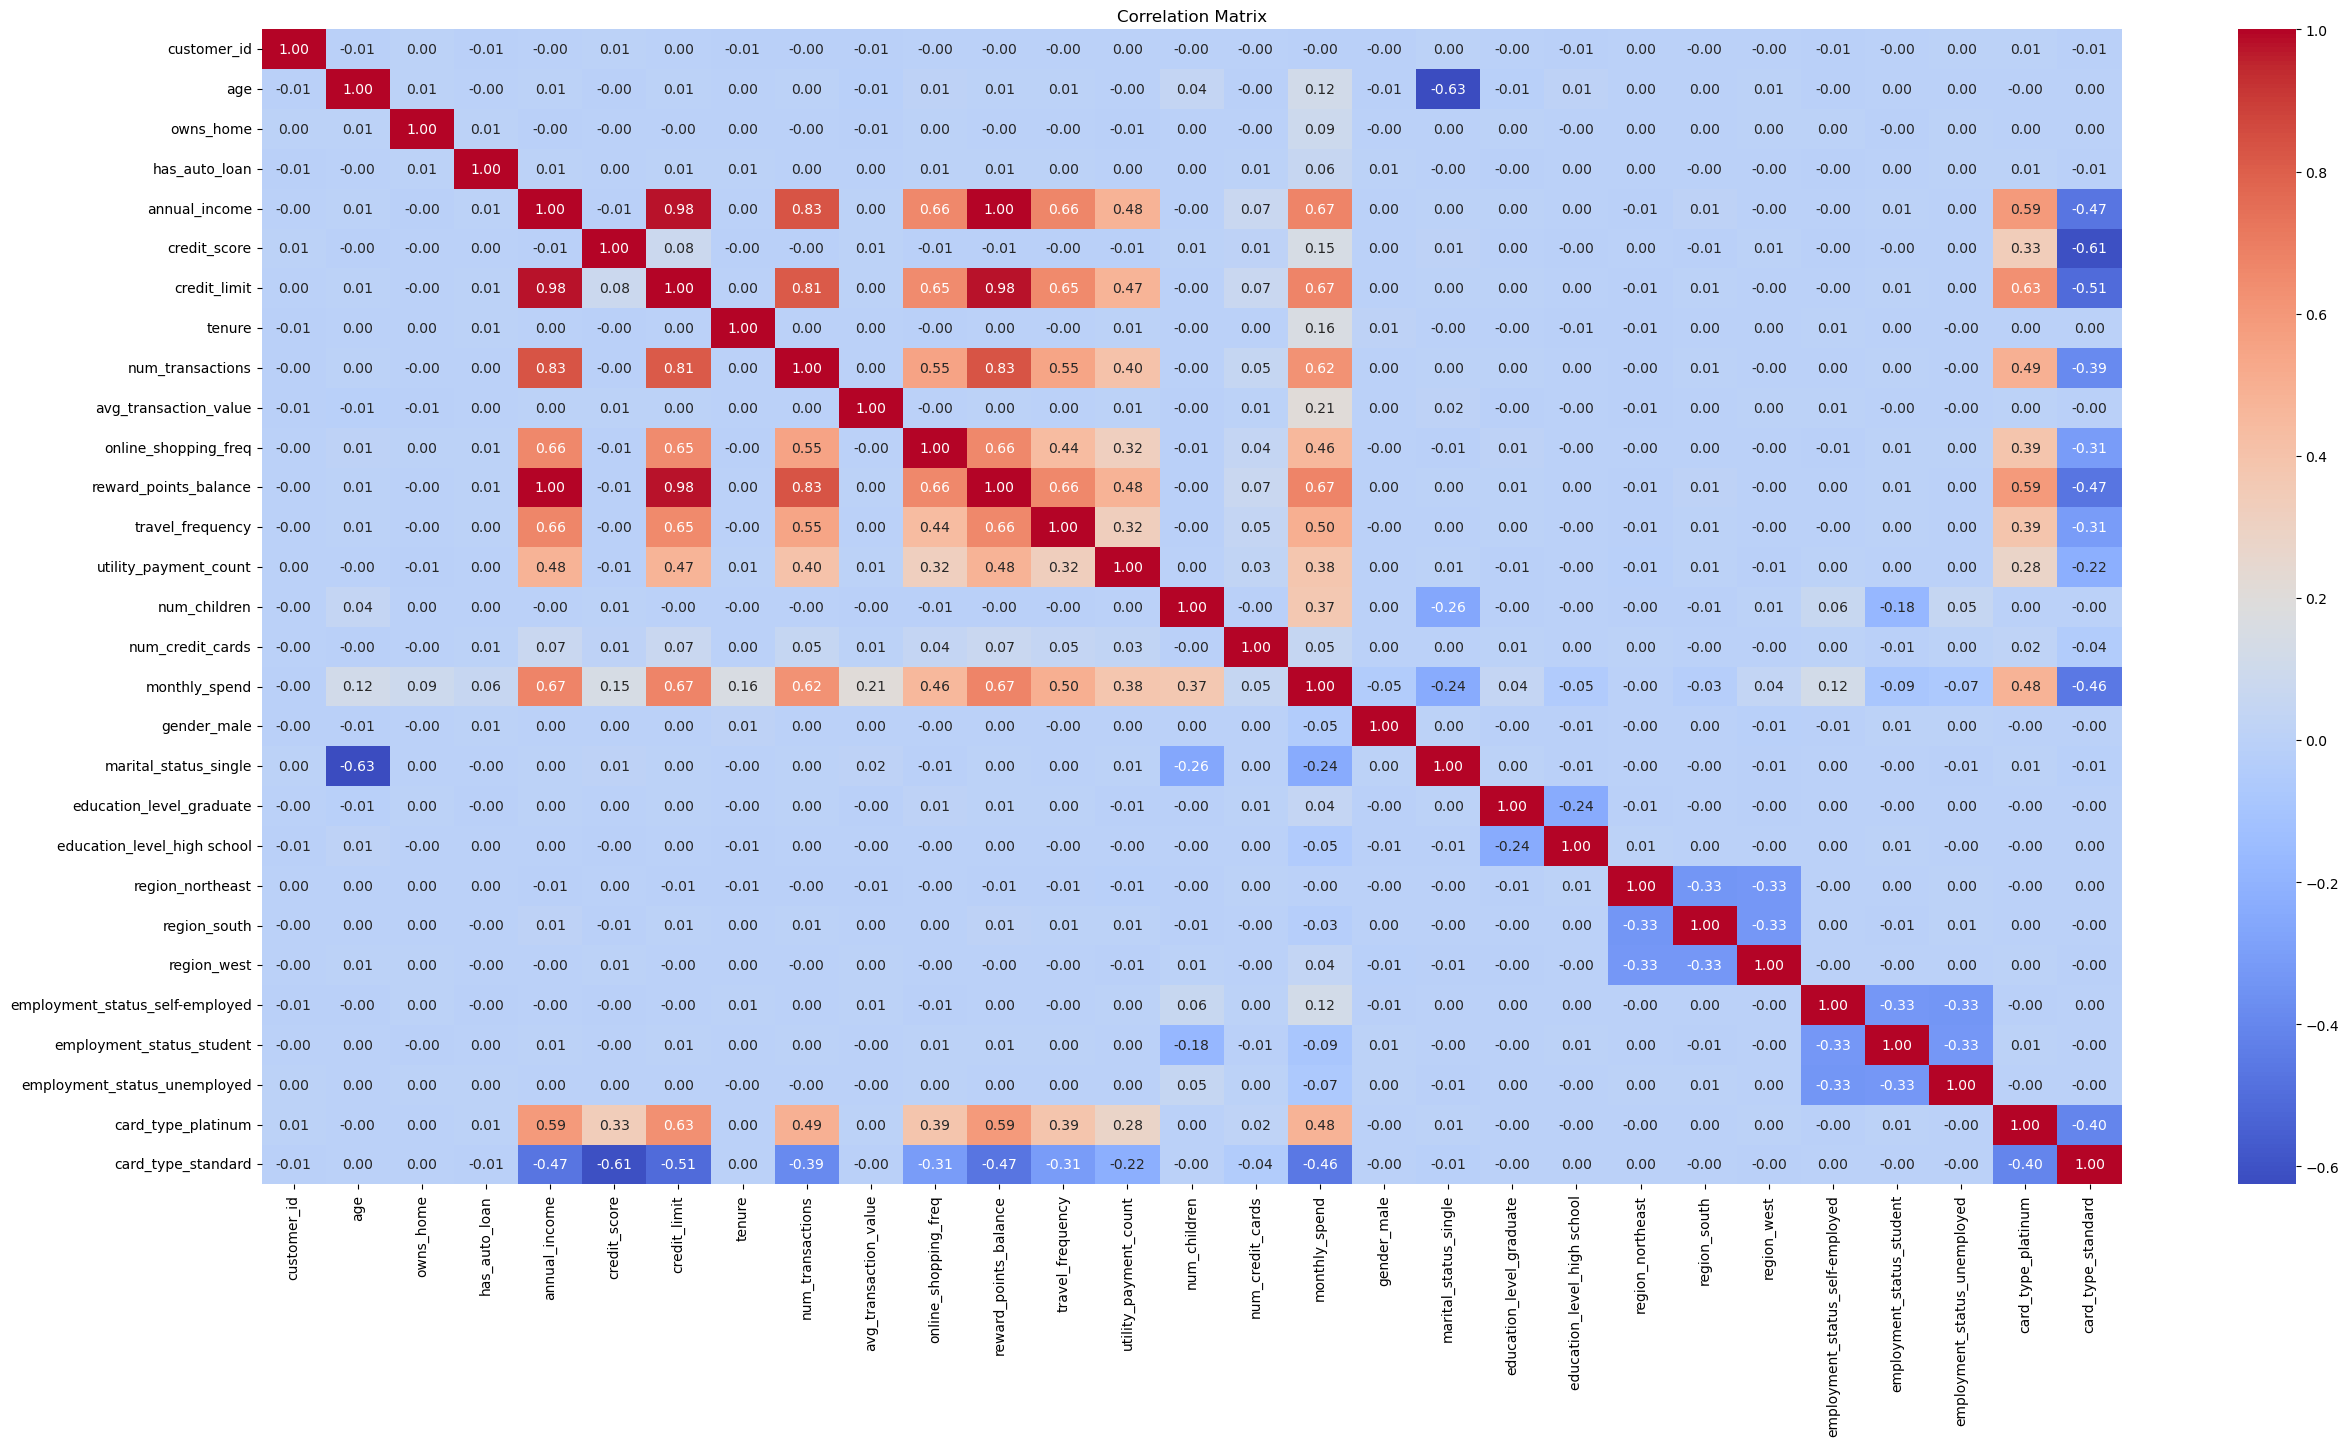

In [7]:
# Check for multicollinearity using the correlation matrix
corr_matrix = data.corr()
plt.figure(figsize=(30, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [8]:
# Drop highly correlated features (if any) to avoid multicollinearity
# For this, we will drop features that have a correlation higher than 0.9 with the target variable or other predictors
high_corr_var = np.where(corr_matrix > 0.9)
high_corr_var = [(corr_matrix.columns[x], corr_matrix.columns[y]) 
                 for x, y in zip(*high_corr_var) if x != y]
print(f"Highly correlated variables: {high_corr_var}")

Highly correlated variables: [('annual_income', 'credit_limit'), ('annual_income', 'reward_points_balance'), ('credit_limit', 'annual_income'), ('credit_limit', 'reward_points_balance'), ('reward_points_balance', 'annual_income'), ('reward_points_balance', 'credit_limit')]


In [9]:
# Feature and target separation
X = data.drop(columns=['monthly_spend', 'customer_id'])
y = data['monthly_spend']

In [10]:
# Assuming X is your feature set, make sure it is correctly assigned:
X = data.drop(columns=['monthly_spend', 'customer_id'])  # Drop the target and customer_id from the feature set

# Separate numerical and categorical columns
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Check if the columns are correctly identified
print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

Numerical columns: Index(['age', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score',
       'credit_limit', 'tenure', 'num_transactions', 'avg_transaction_value',
       'online_shopping_freq', 'reward_points_balance', 'travel_frequency',
       'utility_payment_count', 'num_children', 'num_credit_cards'],
      dtype='object')
Categorical columns: Index([], dtype='object')


In [11]:
# Assuming X is your feature set, make sure it is correctly assigned:
X = data.drop(columns=['monthly_spend', 'customer_id'])  # Drop the target and customer_id from the feature set

# Separate numerical columns (all columns in this case)
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns

# Check if the numerical columns are correctly identified
print(f"Numerical columns: {numerical_cols}")

Numerical columns: Index(['age', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score',
       'credit_limit', 'tenure', 'num_transactions', 'avg_transaction_value',
       'online_shopping_freq', 'reward_points_balance', 'travel_frequency',
       'utility_payment_count', 'num_children', 'num_credit_cards'],
      dtype='object')


In [12]:
# Impute missing values for numerical columns using the 'mean' strategy
numerical_imputer = SimpleImputer(strategy='mean')
X[numerical_cols] = numerical_imputer.fit_transform(X[numerical_cols])

# After imputation, check if any NaN values remain
print(f"Missing values after imputation: \n{X.isna().sum()}")

# Standardize the numerical data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Missing values after imputation: 
age                                0
owns_home                          0
has_auto_loan                      0
annual_income                      0
credit_score                       0
credit_limit                       0
tenure                             0
num_transactions                   0
avg_transaction_value              0
online_shopping_freq               0
reward_points_balance              0
travel_frequency                   0
utility_payment_count              0
num_children                       0
num_credit_cards                   0
gender_male                        0
marital_status_single              0
education_level_graduate           0
education_level_high school        0
region_northeast                   0
region_south                       0
region_west                        0
employment_status_self-employed    0
employment_status_student          0
employment_status_unemployed       0
card_type_platinum                 0
card

In [13]:
# Split the data into training and testing sets
y = data['monthly_spend']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=2101)

In [14]:
# Initialize models for stacking (Random Forest, Gradient Boosting, and Linear Regression)
rf_model = RandomForestRegressor(n_estimators=100, random_state=2101)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=2101)
lr_model = LinearRegression()

In [15]:
# Train models and predict on both training and test data
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
# Make predictions on training and testing data
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

In [17]:
# Calculate RMSE for training and test datasets

train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

train_rmse_gb = np.sqrt(mean_squared_error(y_train, y_train_pred_gb))
test_rmse_gb = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))

train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

print(f"Train RMSE (Random Forest): {train_rmse_rf}, Test RMSE (Random Forest): {test_rmse_rf}")
print(f"Train RMSE (Gradient Boosting): {train_rmse_gb}, Test RMSE (Gradient Boosting): {test_rmse_gb}")
print(f"Train RMSE (Linear Regression): {train_rmse_lr}, Test RMSE (Linear Regression): {test_rmse_lr}")

Train RMSE (Random Forest): 103.57425129257055, Test RMSE (Random Forest): 271.22584353522745
Train RMSE (Gradient Boosting): 254.49568240080941, Test RMSE (Gradient Boosting): 258.56543708454586
Train RMSE (Linear Regression): 258.1507383873912, Test RMSE (Linear Regression): 254.4595168956586


In [18]:
# Model stacking: Average the predictions
y_train_pred_stack = (y_train_pred_rf + y_train_pred_gb + y_train_pred_lr) / 3
y_test_pred_stack = (y_test_pred_rf + y_test_pred_gb + y_test_pred_lr) / 3

In [19]:
# Calculate RMSE for stacked model
train_rmse_stack = np.sqrt(mean_squared_error(y_train, y_train_pred_stack))
test_rmse_stack = np.sqrt(mean_squared_error(y_test, y_test_pred_stack))

print(f"Train RMSE (Stacked Model): {train_rmse_stack}, Test RMSE (Stacked Model): {test_rmse_stack}")

Train RMSE (Stacked Model): 200.60597824926617, Test RMSE (Stacked Model): 255.22893198269264


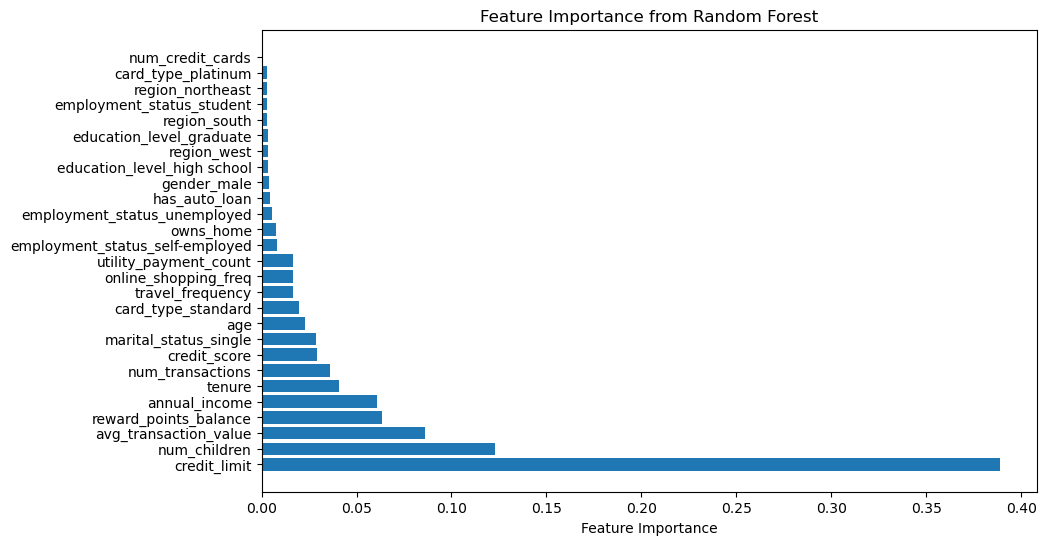

In [20]:
# Feature Importance from RandomForest (to see what features matter most)
feature_importances = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importance from Random Forest")
plt.barh(range(len(feature_importances)), feature_importances[sorted_idx], align='center')
plt.yticks(range(len(feature_importances)), X.columns[sorted_idx])
plt.xlabel("Feature Importance")
plt.show()

In [21]:
# Prepare the scoring data and apply the same transformations

In [23]:
# Handle missing values in scoring data
scoring_data[numerical_cols] = numerical_imputer.transform(scoring_data[numerical_cols])

In [24]:
# After imputation, check if any NaN values remain in the scoring data
print(f"Missing values after imputation in scoring data: \n{scoring_data.isna().sum()}")

Missing values after imputation in scoring data: 
customer_id                0
age                        0
gender                     0
marital_status             0
education_level          301
region                     0
employment_status          0
owns_home                  0
has_auto_loan              0
annual_income              0
credit_score               0
credit_limit               0
tenure                     0
card_type                  0
num_transactions           0
avg_transaction_value      0
online_shopping_freq       0
reward_points_balance      0
travel_frequency           0
utility_payment_count      0
num_children               0
num_credit_cards           0
dtype: int64


In [25]:
# Create dummy variables for categorical columns in scoring data (if needed)
# Note: You don't need to impute categorical data because there are no categorical columns in the scoring data.
scoring_data = pd.get_dummies(scoring_data, columns=['gender', 'marital_status', 'education_level', 'region', 'employment_status', 'card_type'], drop_first=True)

In [26]:
# Make sure the same columns exist in both training and scoring data
scoring_data_X = scoring_data.drop(columns=['customer_id'])

In [27]:
# Align the columns in scoring data with training data (if there are any missing columns in scoring data)
missing_cols = set(X.columns) - set(scoring_data_X.columns)
for col in missing_cols:
    scoring_data_X[col] = 0  # Add missing columns with zeroes

In [28]:
# Standardize the scoring data using the same scaler
scoring_data_X_scaled = scaler.transform(scoring_data_X)

In [29]:
# Generate predictions from the stacked model
scoring_predictions = (rf_model.predict(scoring_data_X_scaled) + 
                       gb_model.predict(scoring_data_X_scaled) + 
                       lr_model.predict(scoring_data_X_scaled)) / 3


In [30]:
# Prepare the submission file
submission_file = pd.DataFrame({
    'customer_id': scoring_data['customer_id'],
    'monthly_spend': scoring_predictions
})

In [31]:
# Save the submission file
submission_file.to_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/Overkill_sub_file.csv', index=False)
print("Submission file created!")

Submission file created!
